In [70]:
import sys
sys.path.append('/..data')
import numpy as np
import pandas as pd
from lab_utils_multi import load_house_data




In [71]:
X_train,Y_train = load_house_data()
X_featuers = ['Sqft' , 'Bedroom' , 'Floors' , 'age']

In [72]:
def zscore(X):
    z1 = np.mean(X, axis=0)
    z2 = np.std(X,axis=0)
    Z_score = (X- z1) /z2

    return Z_score

In [73]:
X_norm = zscore(X_train)
print(f'Raw : {np.ptp(X_train , axis=0)}')
print(f'Normalized : {np.ptp(X_norm , axis=0)}')

Raw : [2.41e+03 4.00e+00 1.00e+00 9.50e+01]
Normalized : [5.85 6.14 2.06 3.69]


In [74]:
def linear_regression(X, w, b):
    m = X.shape[0]
    f_wb = np.zeros((m,))
    x_column = 0
    for i in range(m):
        f_wb[i] = w * X[i,x_column] + b
    return f_wb


In [75]:
w = 100
b = 200
import matplotlib.pyplot as plt

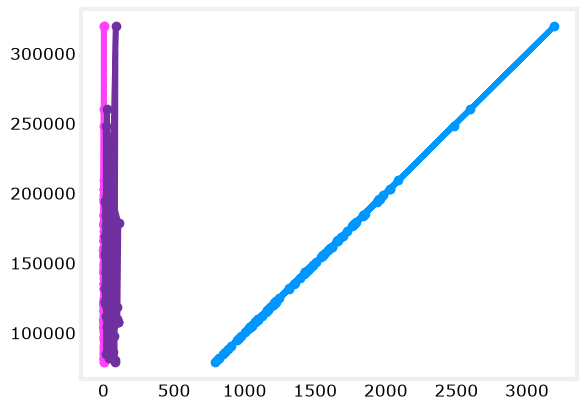

In [76]:
f_wb = linear_regression(X_train,w,b)
plt.plot(X_train,f_wb , marker = 'o')




In [77]:
def compute_cost(X,y,w,b):
    m = X.shape[0]
    cost = 0
    for i in range(m):
        f_wb_i = np.dot(X[i],w) + b
        cost = cost + (f_wb_i - y[i]) ** 2
    cost = cost/(2 * m)


    return cost

In [78]:
w_init = np.zeros(X_norm.shape[1])
b_init = 0.0

In [79]:
cost = compute_cost(X_norm,Y_train,w_init,b_init)

In [80]:
print(f"Your cost : {cost}")


Your cost : 71369.2230479192


In [81]:
def compute_gradient(X,y,w,b):
    m,n = X.shape

    dj_dw = np.zeros(n)
    dj_db = 0
    for i in range(m) :
        f_wb_i = np.dot(X[i],w) + b
        err = f_wb_i - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err * X[i,j]
        dj_db = dj_db + err

    dj_db = dj_db/m
    dj_dw = dj_dw/m
    return dj_dw,dj_db

In [82]:
w_init = np.zeros(X_norm.shape[1])
b_init = 0.0

dj_dw,dj_db = compute_gradient(X_norm,Y_train,w_init,b_init)
print(f"dj_dw : { dj_dw}")
print(f"dj_db : { dj_db}")
import copy



dj_dw : [-89.14 -29.52 -32.82  59.61]
dj_db : -363.1560808080808


In [83]:
def gradient_descent(X,y,w_init,b_init,alpha,num_iters):
    J_hist = []
    w = copy.deepcopy(w_init)
    b = b_init
    for i in range(num_iters):
        dj_dw,dj_db = compute_gradient(X,y,w,b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        J_hist.append(compute_cost(X,y,w,b))
    return w, b, J_hist

In [84]:
w_init = np.zeros(X_norm.shape[1])
b_init = 0.0
alpha = 0.1
iterations = 10000

W_final,B_final,Cost_history= gradient_descent(X_norm,Y_train,w_init,b_init,alpha,iterations)


In [85]:
print(f"w,b found by gradient descent {W_final,B_final}")

w,b found by gradient descent (array([110.56, -21.27, -32.71, -37.97]), np.float64(363.15608080808056))


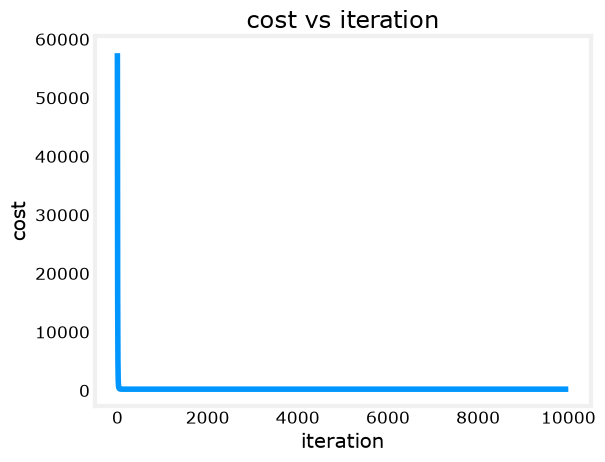

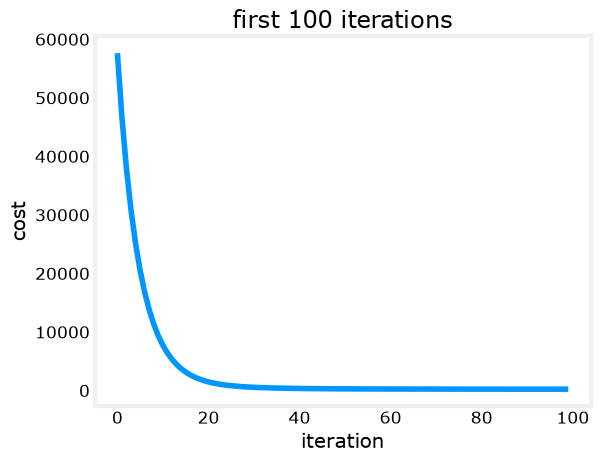

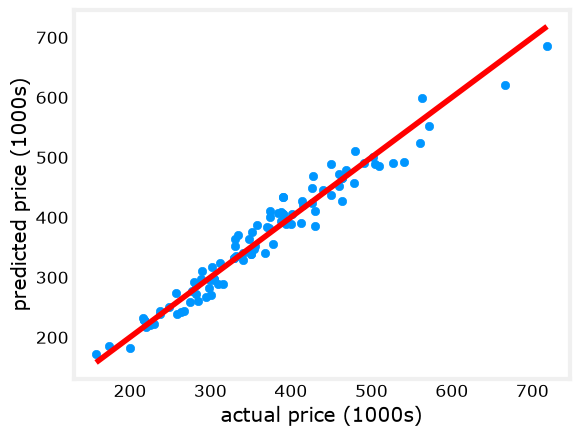

In [86]:
plt.plot(Cost_history)
plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("cost vs iteration")
plt.show()

plt.plot(Cost_history[:100])
plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("first 100 iterations")
plt.show()
y_pred = X_norm @ W_final + B_final
plt.scatter(Y_train, y_pred)
lims = [Y_train.min(), Y_train.max()]
plt.plot(lims, lims, color="red")
plt.xlabel("actual price (1000s)")
plt.ylabel("predicted price (1000s)")
plt.show()

In [104]:
X_new = np.array([[100,3,1,40]])
def zscore(X):
    z1 = np.mean(X, axis=0)
    z2 = np.std(X,axis=0)
    Z_score = (X- z1) /z2

    return Z_score , z1, z2

def linear_regression(X, w, b):
    m = X.shape[0]
    f_wb = np.zeros(m)

    for i in range(m):
        f_wb[i] = np.dot(X[i],w) + b
    return f_wb


X_norm,mu,sigma= zscore(X_train)
predict = linear_regression(X_norm ,W_final,B_final)
print(predict.shape,np.allclose(predict,X_norm@ W_final + B_final))
print(predict.shape, np.allclose(predict, X_norm @ W_final + B_final))
X_new_norm = (X_new - mu) / sigma
predict = linear_regression(X_new_norm, W_final,B_final)
for name,value in zip(X_featuers,X_new[0]):
    print(f"{name} : {value}")

print(f"predicted price: {predict[0]:.1f} thousand dollars (about ${predict[0] * 1000:,.0f})")


(99,) True
(99,) True
Sqft : 100
Bedroom : 3
Floors : 1
age : 40
predicted price: 23.2 thousand dollars (about $23,248)
